In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [109]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 3, 1)) & (dataset.data.index < datetime.datetime(2024, 5, 10))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 20)) & (dataset.data.index < datetime.datetime(2025, 1, 30)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [110]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")

Initializing TGRAD Sensors: 100%|██████████| 48/48 [00:13<00:00,  3.45sensor/s]


In [111]:
tgrad.calibrate(calibName="LN2023_TREE_AVG")

Equalizing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:13<00:00,  3.45sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  42%|████▏     | 20/48 [00:00<00:00, 62.21sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 63.55sensor/s]


In [3]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

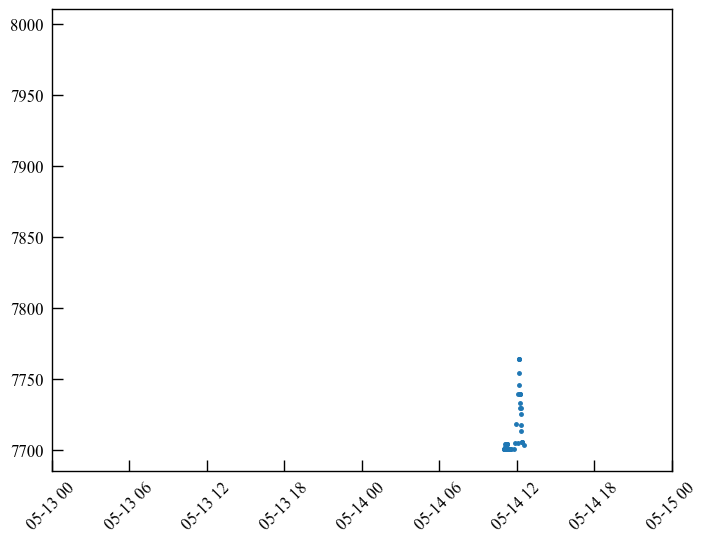

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level2.data.loc[(cryostat_height*level2.data/100>7700)&(cryostat_height*level2.data/100<8000)].index, cryostat_height*level2.data.loc[(cryostat_height*level2.data/100>7700)&(cryostat_height*level2.data/100<8000)].values/100, ".", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-5-13"), pd.Timestamp("2024-5-15"))
axes.tick_params(axis='x', rotation=45)


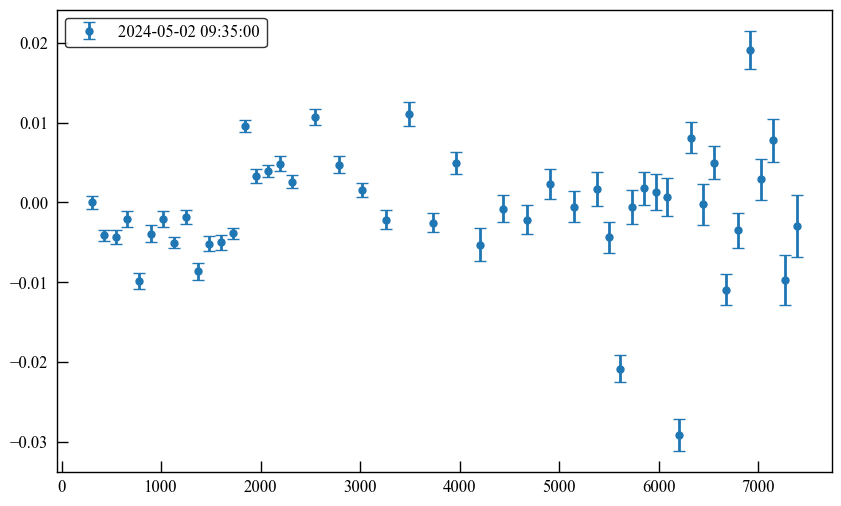

In [105]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# tgrad.makeProfiles(tini=datetime.datetime(2024, 3, 10, 8, 45, 0), tend=datetime.datetime(2024, 3, 10, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-03-10 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 3, 20, 8, 45, 0), tend=datetime.datetime(2024, 3, 20, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-03-20 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 3, 30, 8, 45, 0), tend=datetime.datetime(2024, 3, 30, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-03-30 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 4, 10, 8, 45, 0), tend=datetime.datetime(2024, 4, 10, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-04-10 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 4, 19, 8, 45, 0), tend=datetime.datetime(2024, 4, 19, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-04-19 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 4, 30, 8, 45, 0), tend=datetime.datetime(2024, 4, 30, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-04-30 08:45:00")
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 35, 0), tend=datetime.datetime(2024, 5, 2, 10, 0, 0))
axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
             tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
             yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
             fmt='o', label="2024-05-02 09:35:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 25, 8, 45, 0), tend=datetime.datetime(2024, 5, 25, 9, 0, 0))
# axes.errorbar(tgrad.profiles["Y"].loc[(tgrad.profiles["temp"]<88)].values,
#              tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0],
#              yerr=tgrad.profiles["err"].loc[(tgrad.profiles["temp"]<88)].values,
#              fmt='o', label="2024-05-25 08:45:00")
axes.legend()

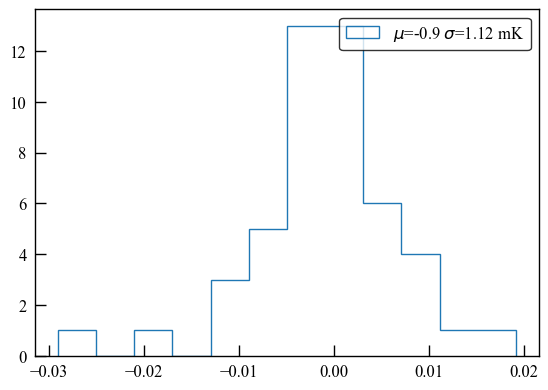

In [106]:
plt.hist(tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], bins=12, histtype="step", label=fr'$\mu$={1e3*tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].values.mean() - 1e3*tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0]:.1f} $\sigma$={1e3*tgrad.profiles["temp"].loc[(tgrad.profiles["temp"]<88)].sem():.2f} mK', color="tab:blue");
plt.legend()